In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 1
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/SSH_GF/UNet_metrics_train.csv"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


# Direct UNet — SSH Reconstruction from Masked Observations

Simplified version of the consistency model notebook.
No generative model — the UNet learns a **direct supervised mapping**:

$$\hat{x} = \text{UNet}(y_\text{filled},\; m,\; \nabla_x J)$$

| Input | Shape | Description |
|-------|-------|-------------|
| $y_\text{filled}$ | `(B, C, H, W)` | Observations with NaN → 0 |
| $m$ | `(B, C, H, W)` | Binary mask (1 = obs available, 0 = NaN) |

The network is trained with MSE loss against the ground truth $x$.


## 🛠️ Setup

In [4]:
!nvidia-smi


Thu Jul 23 15:04:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:E3:00.0 Off |                    0 |
| N/A   33C    P0             61W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

### Imports

In [6]:
import json
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningDataModule, LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchinfo import summary

import sys
sys.path.append('../../..')


## 🧠 Implementation

### DataModule

Norm stats (0.3047108663749711, 0.3879814586804132)


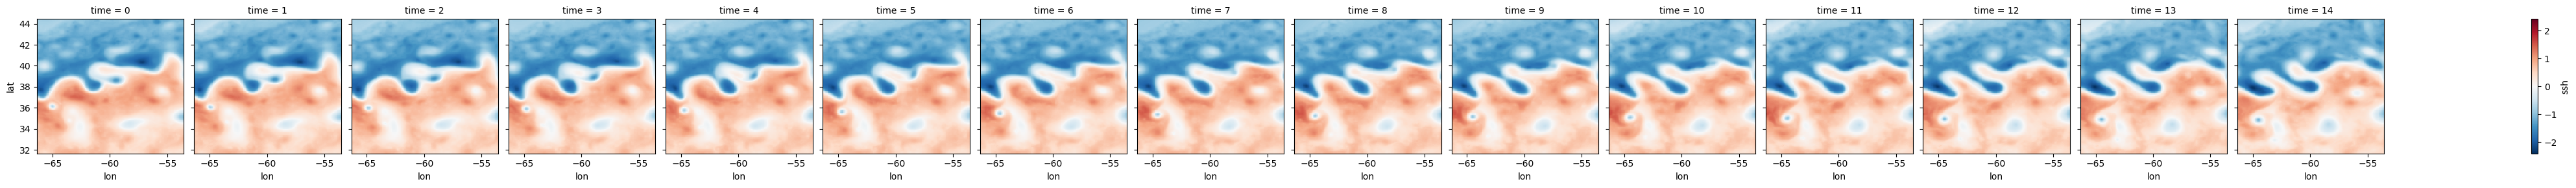

In [7]:
import sys
import pyinterp
import pyinterp.fill
import pyinterp.backends.xarray
from src.data_notebook import *

import matplotlib.pyplot as plt
import torch
import itertools

lon_min = -66.3
lon_max = -53.5
lat_min = 31.7
lat_max = 44.5

datadir = "../../../data"

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

def remove_nan(da):
    da["lon"] = da.lon.assign_attrs(units="degrees_east")
    da["lat"] = da.lat.assign_attrs(units="degrees_north")
    da.transpose("lon", "lat", "time")[:, :] = pyinterp.fill.gauss_seidel(
        pyinterp.backends.xarray.Grid3D(da)
    )[1]
    return da

def load_altimetry_data(path, obs_from_tgt=False):
    ds = (
        xr.open_dataset(path)
        .load()
        .assign(
            input=lambda ds: ds.nadir_obs,
            tgt=lambda ds: remove_nan(ds.ssh),
        )
    )
    if obs_from_tgt:
        ds = ds.assign(input=ds.tgt.where(np.isfinite(ds.input), np.nan))
    return (
        ds[[*TrainingItem._fields]]
        .transpose("time", "lat", "lon")
        .to_array()
    )

datamodule = BaseDataModule(
    input_da=load_altimetry_data(datadir + "/natl_gf_w_5nadirs_swot.nc"),
    domains={
        'train': {'time': slice('2013-02-24', '2013-09-30')},
        'val':   {'time': slice('2012-12-15', '2013-02-24')},
        'test':  {'time': slice('2012-10-01', '2012-12-20')},
    },
    xrds_kw={
        'patch_dims':    {'time': 15, 'lat': 128, 'lon': 128},
        'strides':       {'time': 1,  'lat': 128, 'lon': 128},
        'domain_limits': dict(lon=slice(lon_min, lon_max),
                              lat=slice(lat_min, lat_max)),
    },
    dl_kw={'batch_size': 4, 'num_workers': 1},
    grad=False,
    resize_factor=2,
)
datamodule.setup()

# Quick sanity plot
xr.Dataset(
    data_vars={'ssh': (('time', 'lat', 'lon'), datamodule.train_ds[0].tgt)},
    coords={
        'time': np.arange(15),
        'lon':  np.arange(lon_min, lon_max, 0.1),
        'lat':  np.arange(lat_min, lat_max, 0.1),
    },
).ssh.plot(col='time', col_wrap=15)


### Modules (UNet blocks — identiques au notebook de référence)

In [8]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.noise_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(noise_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.noise_level_projection(cond)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, noise_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, cond))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


### UNet direct

Le réseau prend en entrée :
- `y_filled` : observations avec NaN → 0  `(B, C, H, W)`
- `mask` : masque binaire 0/1  `(B, C, H, W)`

Les deux sont projetés séparément puis **additionnés** avant le premier bloc encodeur (même logique que `input_projection` + `grad_j_projection` dans le notebook de référence).

Il n'y a **pas d'embedding temporel** : le conditioning est remplacé par un vecteur nul de même forme, ignoré par les blocs.

In [9]:
@dataclass
class DirectUNetConfig:
    channels: int = 15                               # C — nb de pas de temps SSH
    cond_channels: int = 1                           # dimension du vecteur de conditioning (inutilisé → 1)
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (128, 128)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (256, 512)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class DirectUNet(nn.Module):
    """
    UNet de reconstruction directe :

        x_hat = UNet(y_filled, mask)

    - y_filled  (B, C, H, W) : observations, NaN remplacés par 0
    - mask      (B, C, H, W) : masque binaire float (1 = obs disponible)

    Les deux signaux sont projetés séparément (C→D) puis additionnés,
    exactement comme input_projection + grad_j_projection dans le notebook
    de référence.  Le conditioning des blocs UNetBlock est un tenseur nul
    de forme (B, 1, 1, 1) — il n'influence pas le calcul mais respecte
    l'interface des blocs réutilisés tels quels.
    """
    def __init__(self, config: DirectUNetConfig) -> None:
        super().__init__()
        self.config = config
        D = config.top_blocks_channels[0]

        self.obs_projection  = nn.Conv2d(config.channels, D, kernel_size=3, padding="same")
        self.mask_projection = nn.Conv2d(config.channels, D, kernel_size=3, padding="same")

        # Conditioning nul : 1 canal → projeté vers la taille attendue par les blocs
        COND = config.cond_channels  # 1

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout,
            self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout,
            self._make_top_block,
        )
        self.output_projection = nn.Conv2d(D, config.channels, kernel_size=3, padding="same")

    def forward(self, y_filled: Tensor, mask: Tensor) -> Tensor:
        """
        Parameters
        ----------
        y_filled : (B, C, H, W)  observations avec NaN→0
        mask     : (B, C, H, W)  masque binaire float

        Returns
        -------
        x_hat : (B, C, H, W)  reconstruction de x
        """
        B = y_filled.shape[0]
        h = self.obs_projection(y_filled) + self.mask_projection(mask)

        # Conditioning nul — forme (B, 1, 1, 1) compatible avec les blocs
        cond = torch.zeros(B, self.config.cond_channels, 1, 1,
                           device=y_filled.device, dtype=y_filled.dtype)

        top_skips = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, cond)
                top_skips.append(h)
            else:
                h = block(h)

        mid_skips = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, cond)
                mid_skips.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_skips.pop()), dim=1)
                h = block(h, cond)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_skips.pop()), dim=1)
                h = block(h, cond)
            else:
                h = block(h)

        return self.output_projection(h)

    # ---- builder helpers (identiques au notebook de référence) ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, self.config.cond_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, self.config.cond_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_direct_unet.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_direct_unet.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "DirectUNet":
        with open(os.path.join(pretrained_path, "config_direct_unet.json"), mode="r") as f:
            config_dict = json.load(f)
        config = DirectUNetConfig(**config_dict)
        model = cls(config)
        state_dict = torch.load(
            os.path.join(pretrained_path, "model_direct_unet.pt"),
            map_location=torch.device("cpu"),
        )
        model.load_state_dict(state_dict)
        return model


summary(
    DirectUNet(DirectUNetConfig()),
    input_size=((1, 15, 128, 128),   # y_filled
                (1, 15, 128, 128)),  # mask
)


Layer (type:depth-idx)                        Output Shape              Param #
DirectUNet                                    [1, 15, 128, 128]         --
├─Conv2d: 1-1                                 [1, 128, 128, 128]        17,408
├─Conv2d: 1-2                                 [1, 128, 128, 128]        17,408
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-1                         [1, 128, 128, 128]        --
│    │    └─Sequential: 3-1                   [1, 128, 128, 128]        147,840
│    │    └─Sequential: 3-2                   [1, 128, 1, 1]            256
│    │    └─Sequential: 3-3                   [1, 128, 128, 128]        147,840
│    │    └─Conv2d: 3-4                       [1, 128, 128, 128]        16,512
│    └─UNetBlock: 2-2                         [1, 128, 128, 128]        --
│    │    └─Sequential: 3-5                   [1, 128, 128, 128]        147,840
│    │    └─Sequential: 3-6                   [1, 128, 1, 1]       

### LitDirectUNet

In [10]:
@dataclass
class LitDirectUNetConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000


class LitDirectUNet(LightningModule):
    """
    Lightning wrapper pour la reconstruction directe par UNet.

    training_step :
        1. Construit y_filled et mask à partir de batch.input (NaN → 0)
        2. Prédit x_hat = model(y_filled, mask)
        3. Loss = MSE(x_hat, batch.tgt)  sur tous les pixels
           (on supervise sur toute la grille, y compris là où il n'y a pas d'obs)
    """

    def __init__(
        self,
        model: nn.Module,
        config: LitDirectUNetConfig = LitDirectUNetConfig(),
    ) -> None:
        super().__init__()
        self.model = model
        self.config = config

    def _prepare_inputs(self, y: Tensor) -> Tuple[Tensor, Tensor]:
        """Retourne (y_filled, mask) depuis y qui contient des NaN."""
        mask     = y.isfinite().to(y.dtype)        # (B, C, H, W) float 0/1
        y_filled = y.nan_to_num(0.0)               # (B, C, H, W) NaN→0
        return y_filled, mask

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        y_filled, mask = self._prepare_inputs(batch.input)
        x_hat = self.model(y_filled, mask)
        loss  = F.mse_loss(x_hat, batch.tgt)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        y_filled, mask = self._prepare_inputs(batch.input)
        x_hat = self.model(y_filled, mask)
        loss  = F.mse_loss(x_hat, batch.tgt)
        rmse  = loss.sqrt()

        self.log_dict({"val_loss": loss, "val_rmse": rmse}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.model.parameters(),
            lr=self.config.lr,
            betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            end_factor=1.0,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step"}]


## 🚀 Training

In [11]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"✅ Checkpoint valide : {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"✅ Checkpoint valide : {ckpt_path}")
            return ckpt_path
    print("❌ Aucun checkpoint valide. Démarrage depuis zéro.")
    return None


@dataclass
class TrainingConfig:
    unet_config: DirectUNetConfig
    lit_config: LitDirectUNetConfig
    trainer: Trainer
    seed: int = 42
    log_dir: str = "logs_direct_unet"
    log_version: str = "v0"
    resume_ckpt_path: Optional[str] = None
    reload: bool = False

    @property
    def run_dir(self) -> str:
        return os.path.join(self.log_dir, self.log_version)

    @property
    def model_ckpt_path(self) -> str:
        return os.path.join(self.run_dir, "best_model")

    @property
    def lightning_ckpt_dir(self) -> str:
        return os.path.join(self.run_dir, "checkpoints")


def run_training(config: TrainingConfig) -> None:
    seed_everything(config.seed)

    if not config.reload:
        model = DirectUNet(config.unet_config)
    else:
        model = DirectUNet.from_pretrained(config.model_ckpt_path)

    lit = LitDirectUNet(model, config.lit_config)

    config.trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
    config.trainer.fit(lit, datamodule, ckpt_path=config.resume_ckpt_path)

    lit.model.save_pretrained(config.model_ckpt_path)
    print(f"✅ Model saved to: {config.model_ckpt_path}")


### Run Training

In [12]:
LOG_DIR     = "logs_direct_unet"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

training_config = TrainingConfig(
    unet_config=DirectUNetConfig(),
    lit_config=LitDirectUNetConfig(lr_scheduler_iters=1000),
    log_dir=LOG_DIR,
    log_version="",
    trainer=Trainer(enable_progress_bar=False, 
        accelerator="gpu",
        max_epochs=MAX_EPOCHS,
        accumulate_grad_batches=4,
        precision="16-mixed",
        log_every_n_steps=1,
        logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
        callbacks=[
            LearningRateMonitor(logging_interval="step"),
            ModelCheckpoint(
                dirpath=CKPT_DIR,
                monitor="val_loss",
                save_top_k=3,
                save_last=True,
                filename="{epoch:03d}-{step}-{val_loss:.4f}",
            ),
        ],
    ),
    #resume_ckpt_path=resume_ckpt,
)
run_training(training_config)


✅ Checkpoint valide : logs_direct_unet/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using 16bit Automatic Mixed Precision (AMP)


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


...

[progress] epoch 1998/2000 | train_loss=0.0002 | val_loss=0.0256 | val_rmse=0.1596


[progress] epoch 1999/2000 | train_loss=0.0002 | val_loss=0.0263 | val_rmse=0.1619


[progress] epoch 2000/2000 | train_loss=0.0001 | val_loss=0.0259 | val_rmse=0.1604


`Trainer.fit` stopped: `max_epochs=2000` reached.


✅ Model saved to: logs_direct_unet/best_model


## 🔍 Évaluation & Visualisation

### Chargement du checkpoint

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

MODEL_PATH = os.path.join("logs_direct_unet", "best_model")

model = DirectUNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)


### Inférence sur un batch test

[rank: 0] Global seed set to 42


RMSE (test batch) : 0.1680
Observations y (NaN → 0) :


Reconstruction UNet x_hat :


Vérité terrain x :


Résidu |x_hat - x| :


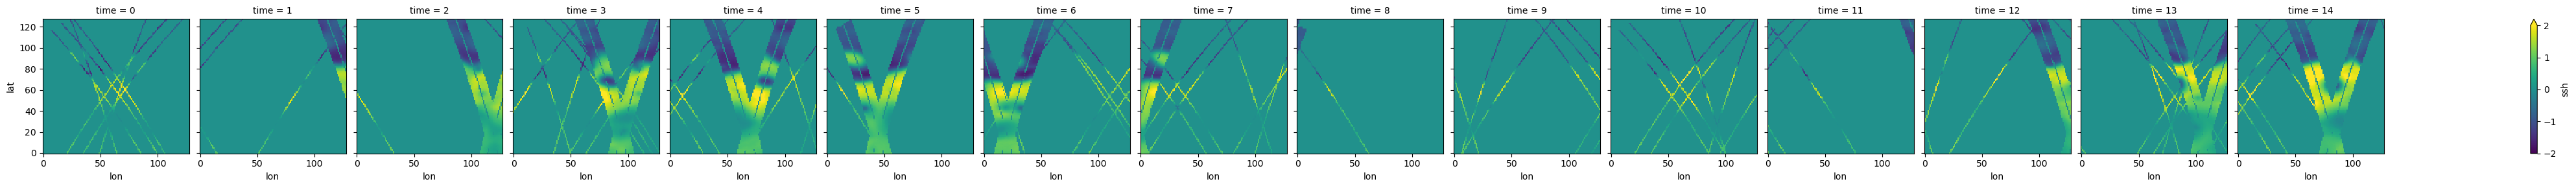

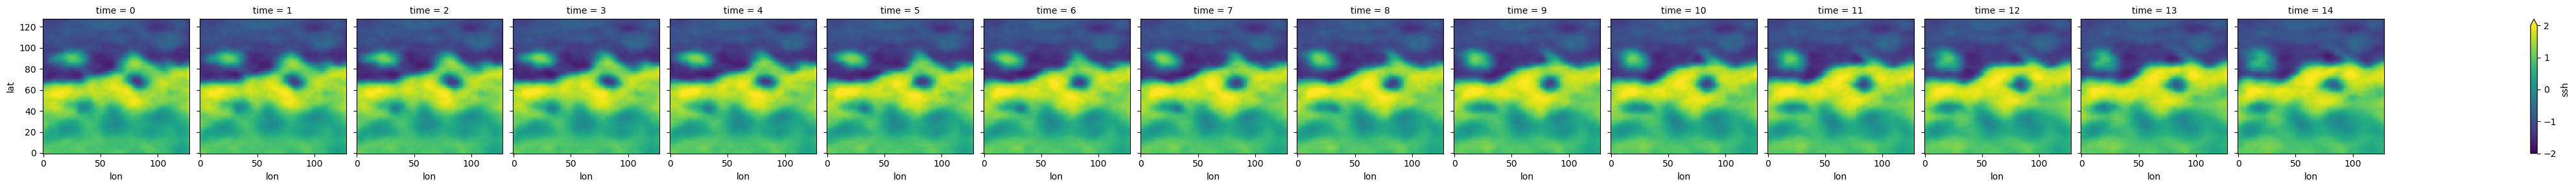

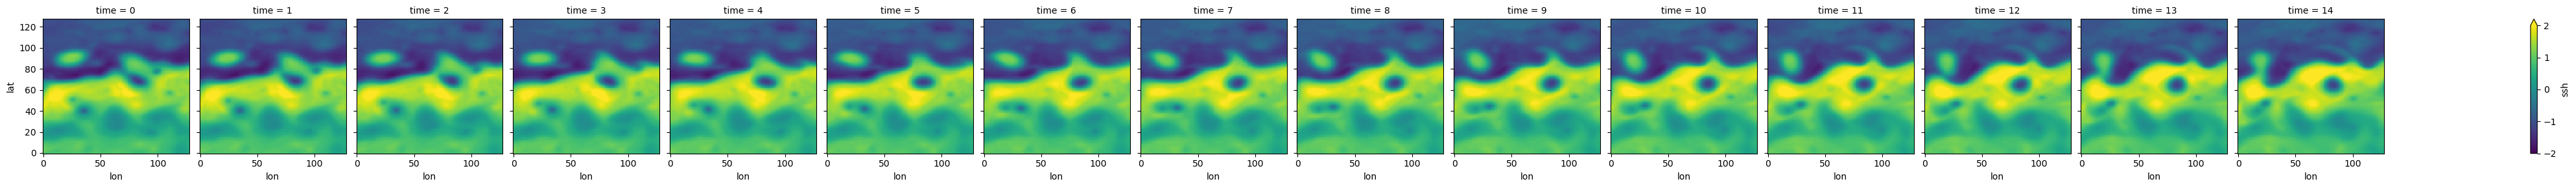

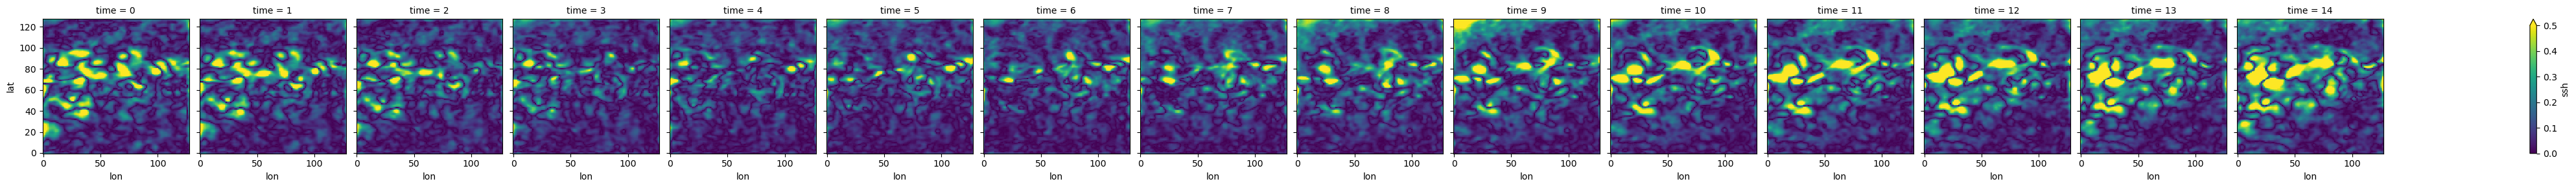

In [14]:
def plot_ssh(images: Tensor, vmin: float = -2., vmax: float = 2., cols: int = 15) -> None:
    """Affiche un champ SSH (C, H, W) comme grille de C cartes."""
    xr.Dataset(
        data_vars={'ssh': (('time', 'lat', 'lon'), images.float().cpu())},
        coords={
            'time': np.arange(images.shape[0]),
            'lon':  np.arange(images.shape[2]),
            'lat':  np.arange(images.shape[1]),
        },
    ).ssh.plot(col='time', col_wrap=cols, vmin=vmin, vmax=vmax)


# ---- Batch de test ----
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

y      = batch.input.to(device=device, dtype=dtype)   # (B, C, H, W)  avec NaN
x_true = batch.tgt  .to(device=device, dtype=dtype)   # (B, C, H, W)

mask     = y.isfinite().to(dtype)
y_filled = y.nan_to_num(0.0)

with torch.no_grad():
    x_hat = model(y_filled, mask)

# ---- Métriques ----
rmse = (x_hat - x_true).pow(2).mean().sqrt().item()
print(f"RMSE (test batch) : {rmse:.4f}")

# ---- Visualisation — premier échantillon du batch ----
b = 0
print("Observations y (NaN → 0) :")
plot_ssh(y_filled[b].cpu())

print("Reconstruction UNet x_hat :")
plot_ssh(x_hat[b].cpu())

print("Vérité terrain x :")
plot_ssh(x_true[b].cpu())

print("Résidu |x_hat - x| :")
plot_ssh((x_hat[b] - x_true[b]).abs().cpu(), vmin=0, vmax=0.5)


In [15]:
import numpy as np
import pandas as pd

# Ground truth and reconstruction (already computed in the previous cell)
gt           = x_true[b].float().cpu().numpy()   # (C, H, W)
x_hat_np     = x_hat  [b].float().cpu().numpy()  # (C, H, W)

# Mask for valid data (non-NaN in ground truth)
valid_mask = ~np.isnan(gt)

# 1. μ-score = 1 - RMSE/std(GT)
gt_std    = np.nanstd(gt)
rmse_val  = np.sqrt(np.nanmean((x_hat_np - gt) ** 2))
mu_score  = 1 - (rmse_val / gt_std)

# 2. Spectral metrics (λx) — minimal resolution reconstructed
def compute_psd_and_lambda_x(field, dx=1.0):
    """
    Compute radial-average PSD and find the wavelength at which PSD drops to 50% of peak.
    dx: grid spacing in km.
    """
    field_valid = field.copy()
    field_valid[np.isnan(field_valid)] = 0

    psd_sum = 0
    for t in range(field_valid.shape[0]):
        fft2d = np.fft.fft2(field_valid[t])
        psd_sum += np.abs(fft2d) ** 2
    psd_avg = psd_sum / field_valid.shape[0]

    ny, nx = psd_avg.shape
    yy, xx = np.meshgrid(np.arange(ny) - ny // 2, np.arange(nx) - nx // 2, indexing='ij')
    rr = np.sqrt(xx ** 2 + yy ** 2)

    r_max = int(np.sqrt((ny // 2) ** 2 + (nx // 2) ** 2))
    radial_psd = np.zeros(r_max)
    for r in range(r_max):
        m = (rr >= r) & (rr < r + 1)
        if np.any(m):
            radial_psd[r] = np.mean(np.fft.fftshift(psd_avg)[m])

    peak_power = np.max(radial_psd[1:])
    threshold  = 0.5 * peak_power
    idx_50 = np.where(radial_psd < threshold)[0]
    lambda_x = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan
    return lambda_x, radial_psd

dx_km = 0.1 * 111  # 0.1° × 111 km/°
lambda_x_gt,    psd_gt    = compute_psd_and_lambda_x(gt,       dx=dx_km)
lambda_x_recon, psd_recon = compute_psd_and_lambda_x(x_hat_np, dx=dx_km)

# 3. Spectral correlation
spectral_score = np.corrcoef(psd_gt[:len(psd_gt) // 2],
                              psd_recon[:len(psd_recon) // 2])[0, 1]

# --- Results table ---
metrics = {
    'Metric': ['μ-score', 'RMSE', 'CRPS', 'λx GT [km]', 'λx Recon [km]', 'Spectral Corr.'],
    'Value': [
        f'{mu_score:.4f}',
        f'{rmse_val:.4f}',
        'N/A (no ensemble)',                                           # ← pas d'ensemble
        f'{lambda_x_gt:.2f}'    if not np.isnan(lambda_x_gt)    else 'N/A',
        f'{lambda_x_recon:.2f}' if not np.isnan(lambda_x_recon) else 'N/A',
        f'{spectral_score:.4f}',
    ],
    'Description': [
        '1 - RMSE/std(GT), higher is better',
        'Root Mean Square Error, lower is better',
        'Not applicable — direct UNet produces a single deterministic output',
        'Minimal resolved wavelength in ground truth',
        'Minimal resolved wavelength in reconstruction',
        'Correlation between GT and recon PSD, higher is better',
    ],
}

df_metrics = pd.DataFrame(metrics)
print("## Performance Assessment")
print()
print(df_metrics.to_markdown(index=False))
print()
print(f"GT std : {gt_std:.4f}")

df_metrics


## Performance Assessment

| Metric         | Value             | Description                                                         |
|:---------------|:------------------|:--------------------------------------------------------------------|
| μ-score        | 0.8238            | 1 - RMSE/std(GT), higher is better                                  |
| RMSE           | 0.1786            | Root Mean Square Error, lower is better                             |
| CRPS           | N/A (no ensemble) | Not applicable — direct UNet produces a single deterministic output |
| λx GT [km]     | 710.40            | Minimal resolved wavelength in ground truth                         |
| λx Recon [km]  | inf               | Minimal resolved wavelength in reconstruction                       |
| Spectral Corr. | 0.9727            | Correlation between GT and recon PSD, higher is better              |

GT std : 1.0135


/tmp/ipykernel_3298089/2431859605.py:45: RuntimeWarning: divide by zero encountered in divide
  lambda_x = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan


,Metric,Value,Description
0,μ-score,0.8238,"1 - RMSE/std(GT), higher is better"
1,RMSE,0.1786,"Root Mean Square Error, lower is better"
2,CRPS,N/A (no ensemble),Not applicable — direct UNet produces a single...
3,λx GT [km],710.40,Minimal resolved wavelength in ground truth
4,λx Recon [km],inf,Minimal resolved wavelength in reconstruction
5,Spectral Corr.,0.9727,"Correlation between GT and recon PSD, higher i..."


In [16]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')


Metrics written to /Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/SSH_GF/UNet_metrics_train.csv
